In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [6]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Nov.csv')
df = df.sample(10000)  
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
3991161,2019-11-03 13:59:48 UTC,view,1005217,2053013555631882655,electronics.smartphone,xiaomi,151.07,525534384,4d75376e-28cc-4b44-8ed5-e34e918fc8be
57489671,2019-11-25 04:38:09 UTC,view,12711358,2053013553559896355,NaN,powertrac,59.20,513443630,96e48654-d0af-4f79-ab7a-31b4c2c59d1b
50833592,2019-11-20 19:09:01 UTC,view,12710968,2053013553559896355,NaN,triangle,30.89,573369998,fbb4f87e-1cdd-44f4-81ee-779bcfbafca9
9164231,2019-11-06 14:50:44 UTC,view,1005195,2053013555631882655,electronics.smartphone,xiaomi,110.17,568220765,7f5f4941-2313-4aea-92cb-dbb9e67714ac
43892840,2019-11-17 14:59:42 UTC,view,1004833,2053013555631882655,electronics.smartphone,samsung,179.15,530066899,aec57464-ee3d-48d1-b1d8-53768ed8df61


In [8]:
funnel = df['event_type'].value_counts()
print(funnel)

event_type
view        9430
cart         457
purchase     113
Name: count, dtype: int64


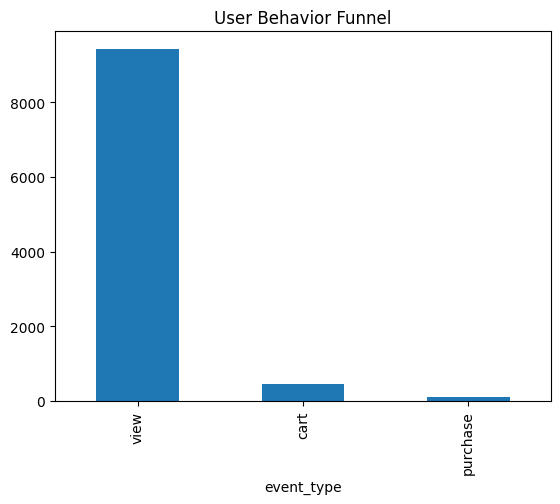

In [11]:
import matplotlib.pyplot as plt
funnel.plot(kind='bar')
plt.title("User Behavior Funnel")
plt.show()

### Most users only view products, while a smaller percentage proceed to cart and purchase

In [12]:
total = len(df)
purchase = len(df[df['event_type'] == 'purchase'])

conversion_rate = purchase / total
print("Conversion rate:", conversion_rate)

Conversion rate: 0.0113


### The overall conversion rate is relatively low, indicating potential issues in the purchase journey

In [13]:
view = len(df[df['event_type'] == 'view'])
cart = len(df[df['event_type'] == 'cart'])
purchase = len(df[df['event_type'] == 'purchase'])

print(view, cart, purchase)

9430 457 113


### A significant drop-off occurs between the view and cart stages, suggesting users are not motivated to add products to cart

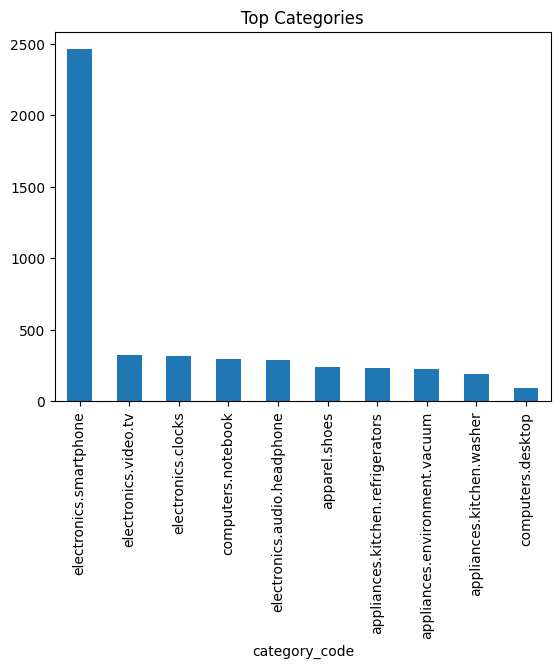

In [14]:
df['category_code'].value_counts().head(10)
df['category_code'].value_counts().head(10).plot(kind='bar')
plt.title("Top Categories")
plt.show()

### Certain product categories attract more user interest, indicating opportunities for targeted marketing

In [16]:
df.groupby('event_type')['price'].mean()

event_type
cart        265.835361
purchase    320.991239
view        291.006232
Name: price, dtype: float64

### Lower-priced products tend to have higher purchase rates

In [17]:
cart_users = set(df[df['event_type']=='cart']['user_id'])
purchase_users = set(df[df['event_type']=='purchase']['user_id'])

abandon_rate = 1 - len(cart_users & purchase_users)/len(cart_users)
print("Cart abandonment rate:", abandon_rate)

Cart abandonment rate: 1.0


### A high cart abandonment rate indicates friction in the checkout process

## Business Recommendations:

- Improve product page UX to encourage add-to-cart actions  
- Simplify checkout process to reduce cart abandonment  
- Focus marketing efforts on high-performing categories  
- Consider pricing strategies to improve conversion rate  
